DIGITAL PAYMENT 

The Digital Payment Fraud Detection dataset contains information about online transactions made in India. It has details like the transaction amount, payment mode, device type, location, account age, login attempts, and IP risk score. Our goal is to use these details to predict whether a transaction is fraud or legitimate. It is a real world dataset which means the features have strong and logical relationships with fraud behavior, making it a great dataset for building a classification model.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

In [2]:
df=pd.read_csv(r"C:\Users\laksh\Downloads\Digital_Payment_Fraud_Detection_Dataset.csv")

In [3]:
df.head()

,transaction_id,user_id,transaction_amount,transaction_type,payment_mode,device_type,device_location,account_age_days,transaction_hour,previous_failed_attempts,avg_transaction_amount,is_international,ip_risk_score,login_attempts_last_24h,fraud_label
0,T1,U3756,18758.28,Transfer,UPI,Web,Hyderabad,895,14,1,25535.84,0,0.718,4,0
1,T2,U7899,47538.18,Payment,Wallet,iOS,Hyderabad,918,21,0,3955.85,0,0.525,9,0
2,T3,U1765,36613.10,Payment,Card,Android,Chennai,1506,8,4,22727.71,0,0.985,9,0
3,T4,U8850,29952.99,Payment,Wallet,iOS,Chennai,800,1,3,18095.89,0,0.797,2,0
4,T5,U9049,7843.13,Payment,UPI,Web,Delhi,301,4,1,9317.49,1,0.468,1,0


In [4]:
df.shape

(7500, 15)

In [5]:
df.describe()

,transaction_amount,account_age_days,transaction_hour,previous_failed_attempts,avg_transaction_amount,is_international,ip_risk_score,login_attempts_last_24h,fraud_label
count,7500.000000,7500.000000,7500.000000,7500.000000,7500.000000,7500.000000,7500.000000,7500.000000,7500.000000
mean,24813.534161,1006.904533,11.435867,2.013600,15129.061027,0.100667,0.505026,4.995067,0.065200
std,14434.742371,575.632925,6.950899,1.421578,8597.760720,0.300907,0.289647,2.593879,0.246895
min,50.580000,10.000000,0.000000,0.000000,102.790000,0.000000,0.000000,1.000000,0.000000
25%,12272.785000,502.750000,5.000000,1.000000,7725.842500,0.000000,0.257000,3.000000,0.000000
50%,24715.550000,1018.000000,11.000000,2.000000,15074.810000,0.000000,0.502000,5.000000,0.000000
75%,37288.375000,1505.000000,18.000000,3.000000,22573.062500,0.000000,0.759000,7.000000,0.000000
max,49985.900000,1999.000000,23.000000,4.000000,29994.290000,1.000000,1.000000,9.000000,1.000000


In [6]:
df.dtypes

transaction_id               object
user_id                      object
transaction_amount          float64
transaction_type             object
payment_mode                 object
device_type                  object
device_location              object
account_age_days              int64
transaction_hour              int64
previous_failed_attempts      int64
avg_transaction_amount      float64
is_international              int64
ip_risk_score               float64
login_attempts_last_24h       int64
fraud_label                   int64
dtype: object

In [7]:
df.isnull().sum()

transaction_id              0
user_id                     0
transaction_amount          0
transaction_type            0
payment_mode                0
device_type                 0
device_location             0
account_age_days            0
transaction_hour            0
previous_failed_attempts    0
avg_transaction_amount      0
is_international            0
ip_risk_score               0
login_attempts_last_24h     0
fraud_label                 0
dtype: int64

In [8]:
df = df.drop(columns=['transaction_id', 'user_id'])
df.head()

,transaction_amount,transaction_type,payment_mode,device_type,device_location,account_age_days,transaction_hour,previous_failed_attempts,avg_transaction_amount,is_international,ip_risk_score,login_attempts_last_24h,fraud_label
0,18758.28,Transfer,UPI,Web,Hyderabad,895,14,1,25535.84,0,0.718,4,0
1,47538.18,Payment,Wallet,iOS,Hyderabad,918,21,0,3955.85,0,0.525,9,0
2,36613.10,Payment,Card,Android,Chennai,1506,8,4,22727.71,0,0.985,9,0
3,29952.99,Payment,Wallet,iOS,Chennai,800,1,3,18095.89,0,0.797,2,0
4,7843.13,Payment,UPI,Web,Delhi,301,4,1,9317.49,1,0.468,1,0


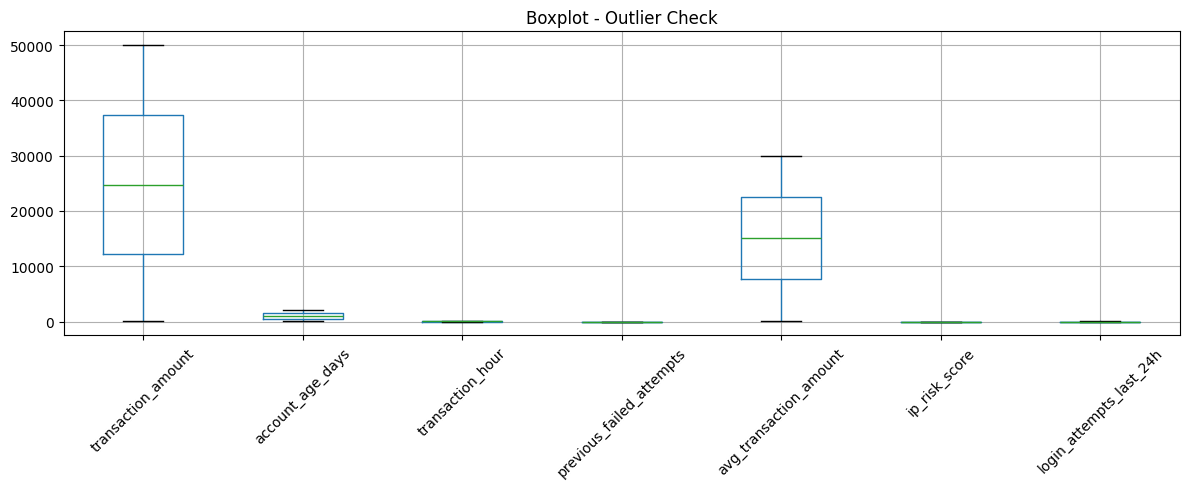

In [9]:
numeric_cols = ['transaction_amount', 'account_age_days', 'transaction_hour',
                'previous_failed_attempts', 'avg_transaction_amount',
                'ip_risk_score', 'login_attempts_last_24h']

df[numeric_cols].boxplot(figsize=(12, 5))
plt.xticks(rotation=45)
plt.title("Boxplot - Outlier Check")
plt.tight_layout()
plt.show()

In [10]:
# Encoding
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

cat_cols = ['transaction_type', 'payment_mode', 'device_type', 'device_location']

for col in cat_cols:
    df[col] = le.fit_transform(df[col])

df.head()

,transaction_amount,transaction_type,payment_mode,device_type,device_location,account_age_days,transaction_hour,previous_failed_attempts,avg_transaction_amount,is_international,ip_risk_score,login_attempts_last_24h,fraud_label
0,18758.28,1,2,1,3,895,14,1,25535.84,0,0.718,4,0
1,47538.18,0,3,2,3,918,21,0,3955.85,0,0.525,9,0
2,36613.10,0,0,0,1,1506,8,4,22727.71,0,0.985,9,0
3,29952.99,0,3,2,1,800,1,3,18095.89,0,0.797,2,0
4,7843.13,0,2,1,2,301,4,1,9317.49,1,0.468,1,0


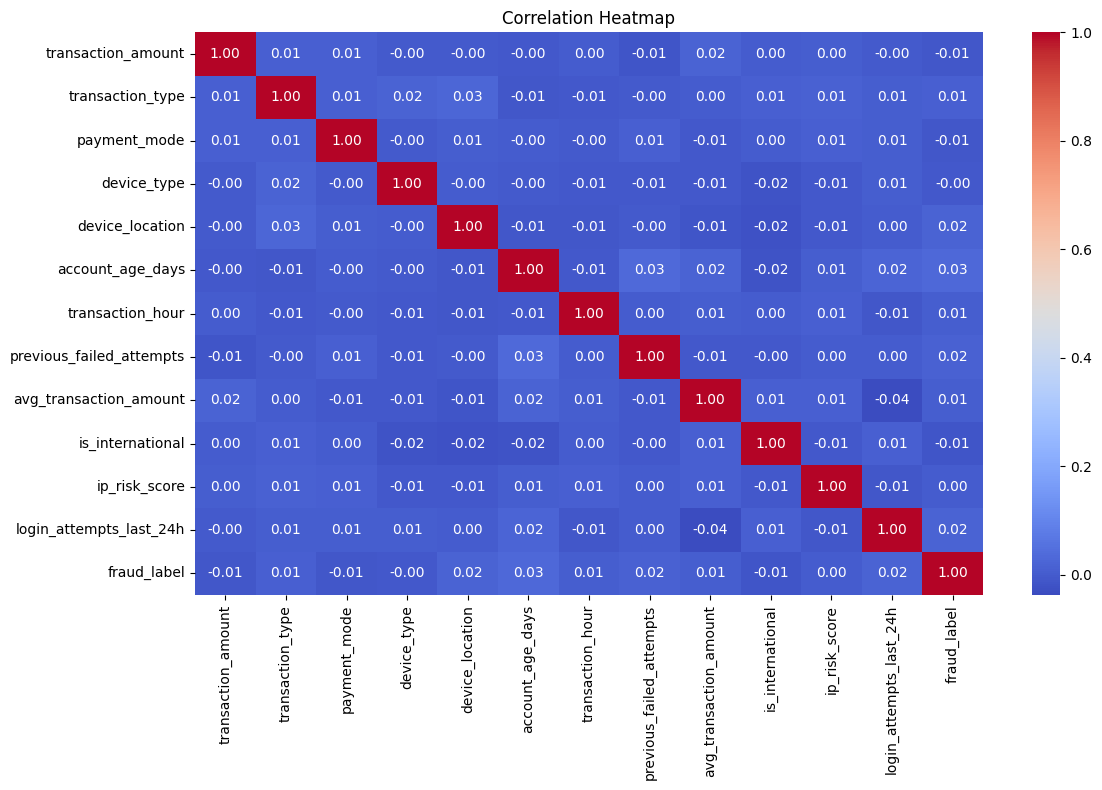

In [11]:
# Heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

In [12]:
# Feature Scaling
scaler = StandardScaler()

scale_cols = ['transaction_amount', 'account_age_days', 'transaction_hour',
              'previous_failed_attempts', 'avg_transaction_amount',
              'ip_risk_score', 'login_attempts_last_24h']

df[scale_cols] = scaler.fit_transform(df[scale_cols])

In [13]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=['fraud_label'])
y = df['fraud_label']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

MODELS

In [14]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

model_lr = LogisticRegression()
model_lr.fit(X_train, y_train)
y_pred_lr = model_lr.predict(X_test)
print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_lr))

Logistic Regression Accuracy: 0.9353333333333333


In [15]:
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score

model_nb = GaussianNB()
model_nb.fit(X_train, y_train)
y_pred_nb = model_nb.predict(X_test)
print("Naive Bayes Accuracy:", accuracy_score(y_test, y_pred_nb))

Naive Bayes Accuracy: 0.9353333333333333


In [16]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

model_dt = DecisionTreeClassifier()
model_dt.fit(X_train, y_train)
y_pred_dt = model_dt.predict(X_test)
print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))

Decision Tree Accuracy: 0.8526666666666667


In [17]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

model_rf = RandomForestClassifier()
model_rf.fit(X_train, y_train)
y_pred_rf = model_rf.predict(X_test)
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))

Random Forest Accuracy: 0.9353333333333333


In [18]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

model_knn = KNeighborsClassifier()
model_knn.fit(X_train, y_train)
y_pred_knn = model_knn.predict(X_test)
print("KNN Accuracy:", accuracy_score(y_test, y_pred_knn))

KNN Accuracy: 0.934


In [19]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

model_svm = SVC()
model_svm.fit(X_train, y_train)
y_pred_svm = model_svm.predict(X_test)
print("SVM Accuracy:", accuracy_score(y_test, y_pred_svm))

SVM Accuracy: 0.9353333333333333


In [20]:
from sklearn.ensemble import AdaBoostClassifier
from sklearn.metrics import accuracy_score

model_ada = AdaBoostClassifier()
model_ada.fit(X_train, y_train)
y_pred_ada = model_ada.predict(X_test)
print("AdaBoost Accuracy:", accuracy_score(y_test, y_pred_ada))

AdaBoost Accuracy: 0.9353333333333333


In [21]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score

model_gb = GradientBoostingClassifier()
model_gb.fit(X_train, y_train)
y_pred_gb = model_gb.predict(X_test)
print("Gradient Boosting Accuracy:", accuracy_score(y_test, y_pred_gb))

Gradient Boosting Accuracy: 0.9346666666666666


In [22]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score

model_xgb = XGBClassifier()
model_xgb.fit(X_train, y_train)
y_pred_xgb = model_xgb.predict(X_test)
print("XGBoost Accuracy:", accuracy_score(y_test, y_pred_xgb))

XGBoost Accuracy: 0.9333333333333333


CONCLUSION

After testing all classification models, most of them performed similarly with around 93.5% accuracy. From all the models, we selected Logistic Regression and XGBoost as our best models.

Logistic Regression is simple, fast and easy to understand. Even though it is a basic model, it achieved the highest accuracy of 93.53% which makes it a great choice for fraud detection.

XGBoost is a powerful model that is widely used in real world fraud detection. It is good at finding complex patterns in data and achieved an accuracy of 93.33% which is very reliable.

Both models together give a good balance between simplicity and power, making them the best fit for detecting fraud in digital payment transactions